In [ ]:
import math
from PIL import Image, ImageDraw
from PIL import ImagePath
import pandas as pd
import os
from os import path
from tqdm import tqdm
import json
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import urllib
import imgaug.augmenters as iaa
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense,Input,Conv2D,MaxPool2D,Activation,Dropout,Flatten, BatchNormalization, ReLU, Reshape
from tensorflow.keras.models import Model
import random as rn
from tensorflow.keras.layers import Flatten
from sklearn.model_selection import train_test_split


**Loading and Preprocessing the Indian Driving Dataset**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
image_dir='/content/drive/MyDrive/data2/images'
import os

In [ ]:
data_df=pd.read_csv('/content/drive/MyDrive/data_df.csv')

In [ ]:
image_list=[]
for i in sorted(os.listdir(image_dir)):
  image_list.append(os.path.join(image_dir,i))

In [ ]:
data_df.head()

In [ ]:
mask_dir='/content/drive/MyDrive/data2/mask'

In [ ]:
mask_list=[]
for i in sorted(os.listdir(mask_dir)):
  mask_list.append(os.path.join(mask_dir,i))

In [ ]:
import pandas as pd
data_df= pd.DataFrame(columns=['image','json'])

In [ ]:
data_df['image']=image_list
data_df['json']=mask_list

In [ ]:
data_df.shape

In [ ]:
data_df.head()

Checking how many unique labels are present in the json files

In [ ]:
import json
from tqdm.auto import tqdm
a=[dir]
def return_unique_labels(data_df):

    for i in tqdm(data_df['json']):
      f = open(i,)
      data =json.load(f)
      for j in data['objects']:
        a.append((j.get('label')))
    return a

In [ ]:
unique_labels = return_unique_labels(data_df)

In [ ]:
def unique(list1):
    list_set = set(list1)
    unique_list = (list(list_set))
    return unique_list
unique_labels=unique(unique_labels)

In [ ]:
len(unique_labels)

In [ ]:
(unique_labels)

In [ ]:
unique_labels.remove(unique_labels[26])

In [ ]:
label_clr = {'road':10, 'parking':20, 'drivable fallback':20,'sidewalk':30,'non-drivable fallback':40,'rail track':40,\
                        'person':50, 'animal':50, 'rider':60, 'motorcycle':70, 'bicycle':70, 'autorickshaw':80,\
                        'car':80, 'truck':90, 'bus':90, 'vehicle fallback':90, 'trailer':90, 'caravan':90,\
                        'curb':100, 'wall':100, 'fence':110,'guard rail':110, 'billboard':120,'traffic sign':120,\
                        'traffic light':120, 'pole':130, 'polegroup':130, 'obs-str-bar-fallback':130,'building':140,\
                        'bridge':140,'tunnel':140, 'vegetation':150, 'sky':160, 'fallback background':160,'unlabeled':0,\

            'out of roi':0, 'ego vehicle':170, 'license plate':80, 'ground':180,'rectification border':190,\
                   'train':200}

Extracting polygons from json files

In [ ]:
def get_poly(file):
    f = open(file,)
    data = json.load(f)
    label,vertexlist=[],[]
    for obj in data['objects']:
        label.append(obj['label'])
        vertexlist.append([tuple(vertex) for vertex in obj['polygon']])
    w= data['imgWidth']
    h=data['imgHeight']
    return w, h, label, vertexlist

In [ ]:
import matplotlib.pyplot as plt
import math
from PIL import Image, ImageDraw
from PIL import ImagePath
import numpy as np

Generating annotation masks from json files by filling polygons with intensity value as per label_clr dictionary

In [ ]:
def compute_masks(data_df):
    mask=[]
    for file in tqdm(data_df['json']):
        w, h, labels, vertexlist = get_poly(file)

        img= Image.new("RGB",(w,h))
        img1 = ImageDraw.Draw(img)
        for i in range(len(labels)):
            if(len(vertexlist[i])>1):
                img1.polygon(vertexlist[i], fill = label_clr[labels[i]])
        img=np.array(img)
        im = Image.fromarray(img[:,:,0])
        new_file=file.replace('mask','output')
        new_file=new_file.replace('json','png')
        os.makedirs('data/output/'+file.split('/')[2],exist_ok=True)
        im.save(new_file)
        mask.append(new_file)
    data_df['mask']=mask

    return data_df

In [ ]:
data_df = compute_masks(data_df)
data_df.head()

Visualising the data

In [ ]:
img=cv2.imread('/content/drive/MyDrive/data2/images/000263_leftImg8bit.png')
plt.imshow(img)

In [ ]:
mask=cv2.imread('/content/drive/MyDrive/data2/output/000263_gtFine_polygons.png')
plt.imshow(mask)

In [ ]:
data_df.to_csv('/content/drive/MyDrive/data_df.csv',index=False)

In [ ]:
import joblib
joblib.dump(data_df,'data.pkl')

In [ ]:
import joblib
data_df = joblib.load('data.pkl')

In [ ]:
import urllib.request

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

Unet Architecture


1.   Encoder path- 4 encoder blocks each with 2 convolutional layers followed by 1 max pooling layer.
2.   Bottle neck- 2 convolutional layers to further extract feautures from encoder output without down sampling.
3. Decoder path  - 4 decoder blocks each with a transpose convolutional layer for upsampling followed by concatenation of convolutional outputs from corresponding encoder blocks (skip connections) and 2 covolutional layers.
Final predictions are obtained by applying softmax activation on output of 1x1 convolution with 21 filters

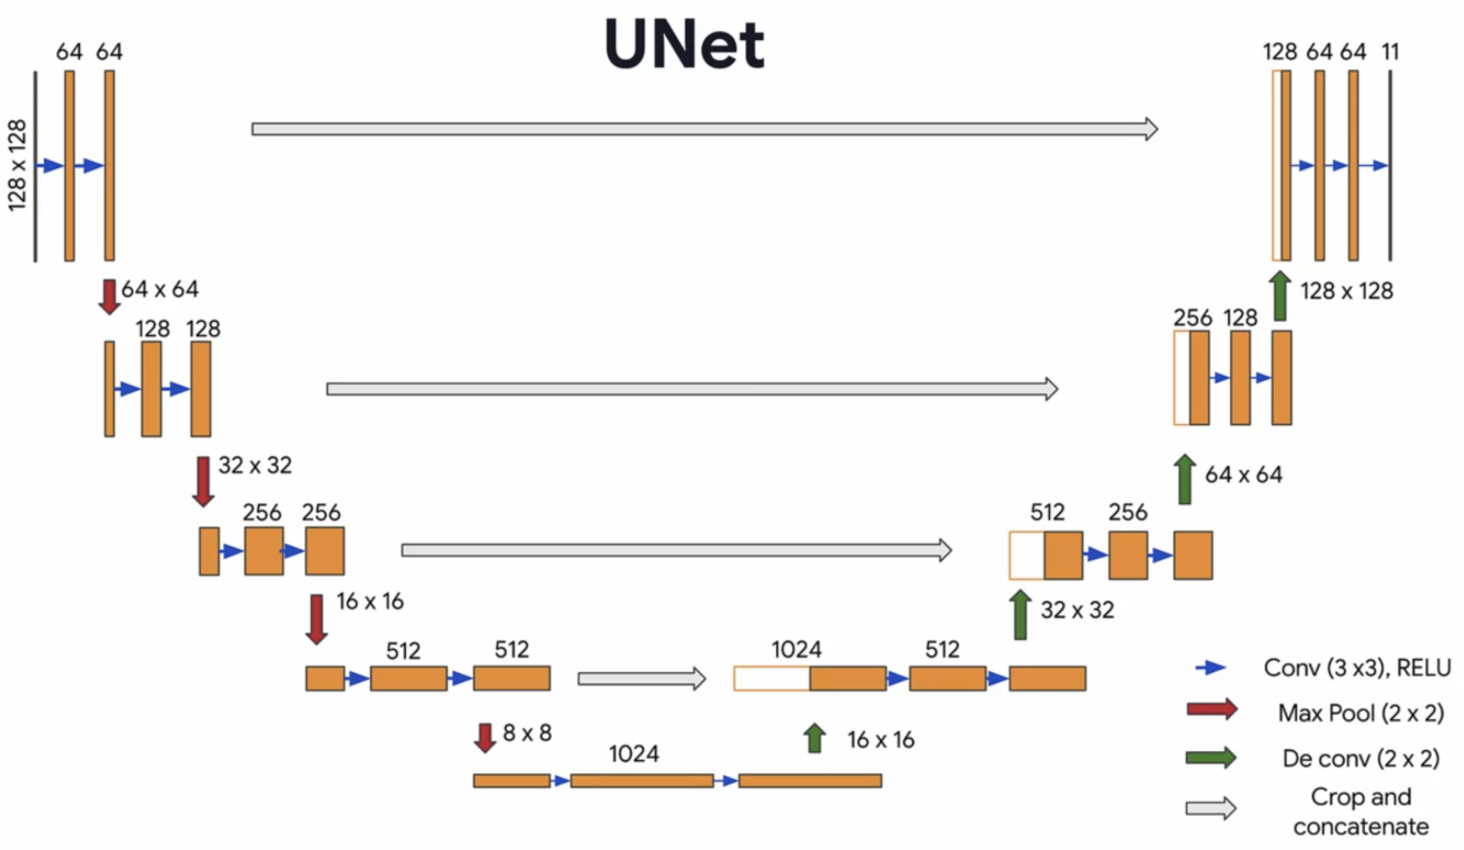

**Encoder Utilities**

In [ ]:
def conv2d_block(input_tensor, n_filters, kernel_size = 3):
  x = input_tensor
  for i in range(2):
    x = tf.keras.layers.Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
            kernel_initializer = 'he_normal', padding = 'same')(x)
    x = tf.keras.layers.Activation('relu')(x)
  return x
def encoder_block(inputs, n_filters=64, pool_size=(2,2), dropout=0.3):
  f = conv2d_block(inputs, n_filters=n_filters)
  p = tf.keras.layers.MaxPooling2D(pool_size=pool_size)(f)
  p = tf.keras.layers.Dropout(0.3)(p)
  return f, p
def encoder(inputs):
  f1, p1 = encoder_block(inputs, n_filters=64, pool_size=(2,2), dropout=0.3)
  f2, p2 = encoder_block(p1, n_filters=128, pool_size=(2,2), dropout=0.3)
  f3, p3 = encoder_block(p2, n_filters=256, pool_size=(2,2), dropout=0.3)
  f4, p4 = encoder_block(p3, n_filters=512, pool_size=(2,2), dropout=0.3)
  return p4, (f1, f2, f3, f4)

**Bottle Neck**

In [ ]:
def bottleneck(inputs):
  bottle_neck = conv2d_block(inputs, n_filters=1024)
  return bottle_neck

**Decoder Utilities**

In [ ]:
# Decoder Utilities

def decoder_block(inputs, conv_output, n_filters=64, kernel_size=3, strides=3, dropout=0.3):

  u = tf.keras.layers.Conv2DTranspose(n_filters, kernel_size, strides = strides, padding = 'same')(inputs)
  c = tf.keras.layers.concatenate([u, conv_output])
  c = tf.keras.layers.Dropout(dropout)(c)
  c = conv2d_block(c, n_filters, kernel_size=3)

  return c


def decoder(inputs, convs, output_channels):


  f1, f2, f3, f4 = convs

  c6 = decoder_block(inputs, f4, n_filters=512, kernel_size=(3,3), strides=(2,2), dropout=0.3)
  c7 = decoder_block(c6, f3, n_filters=256, kernel_size=(3,3), strides=(2,2), dropout=0.3)
  c8 = decoder_block(c7, f2, n_filters=128, kernel_size=(3,3), strides=(2,2), dropout=0.3)
  c9 = decoder_block(c8, f1, n_filters=64, kernel_size=(3,3), strides=(2,2), dropout=0.3)

  outputs = tf.keras.layers.Conv2D(output_channels, (1, 1), activation='softmax')(c9)
  #outputs=tf.keras.layers.Flatten()(outputs)
  #outputs=tf.squeeze(outputs)

  return outputs



In [ ]:
OUTPUT_CHANNELS = 21

def unet():

  inputs = tf.keras.layers.Input(shape=(256,256,3))
  encoder_output, convs = encoder(inputs)
  bottle_neck = bottleneck(encoder_output)
  outputs = decoder(bottle_neck, convs, output_channels=OUTPUT_CHANNELS)
  model = tf.keras.Model(inputs=inputs, outputs=outputs)
  return model
model = unet()
model.summary()

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test = train_test_split(data_df, test_size=0.11, random_state=42)

image augmentation utilities to prevent over fitting

In [ ]:
import imgaug.augmenters as iaa
aug2 = iaa.Fliplr(1)
aug3 = iaa.Flipud(1)
aug4 = iaa.Emboss(alpha=(1), strength=1)
aug5 = iaa.DirectedEdgeDetect(alpha=(0.8), direction=(1.0))
aug6 = iaa.Sharpen(alpha=(1.0), lightness=(1.5))

In [ ]:
def visualize(**images):
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(' '.join(name.split('_')).title())
        if i==1:
            plt.imshow(image, cmap='gray', vmax=1, vmin=0)
        else:
            plt.imshow(image)
    plt.show()


class Dataset:

    def __init__(self , basepath , images_file_names , mask_file_names , CLASSES):

        self.image_ids = images_file_names
        self.mask_ids = mask_file_names
        self.images_fps   = [os.path.join(basepath,image_id) for image_id in self.image_ids]
        self.masks_fps    = [os.path.join(basepath,mask_id) for mask_id in self.mask_ids]
        self.CLASSES= CLASSES
        self.class_values = CLASSES

    def __getitem__(self, i):

        # read data
        image = cv2.imread(self.images_fps[i], cv2.IMREAD_UNCHANGED)
        image = cv2.resize(image,(256,256),interpolation=cv2.INTER_NEAREST)
        #image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


        mask  = cv2.imread(self.masks_fps[i], cv2.IMREAD_UNCHANGED)
        image_mask = cv2.resize(mask,(256,256))
        image_masks = [(image_mask == v) for v in self.class_values]
        image_mask = np.stack(image_masks, axis=-1).astype('float')

        if self.images_fps[i] in x_train:
          a = np.random.uniform()
          if a<0.2:
              image = aug2.augment_image(image)
              image_mask = aug2.augment_image(image_mask)
          elif a<0.4:
              image = aug3.augment_image(image)
              image_mask = aug3.augment_image(image_mask)
          elif a<0.6:
              image = aug4.augment_image(image)
              image_mask = aug4.augment_image(image_mask)
          elif a<0.8:
              image = aug5.augment_image(image)
              image_mask = image_mask
          else:
              image = aug6.augment_image(image)
              image_mask = aug6.augment_image(image_mask)

        return image, image_mask

    def __len__(self):
        return len(self.image_ids)


class Dataloder(tf.keras.utils.Sequence):
    def __init__(self, dataset, batch_size=1, shuffle=False):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(dataset))

    def __getitem__(self, i):

        # collect batch data
        start = i * self.batch_size
        stop = (i + 1) * self.batch_size
        data = []
        for j in range(start, stop):
            data.append(self.dataset[j])

        batch = [np.stack(samples, axis=0) for samples in zip(*data)]

        return tuple(batch)

    def __len__(self):
        return len(self.indexes) // self.batch_size

    def on_epoch_end(self):
        if self.shuffle:
            self.indexes = np.random.permutation(self.indexes)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
CLASSES = list(np.unique(list(label_clr.values())))

In [ ]:
print(len(CLASSES))

In [ ]:
from keras.callbacks import Callback, ModelCheckpoint,TensorBoard,ReduceLROnPlateau
from keras.callbacks import TensorBoard
import time
# import datetime
!rm -rf '/content/logs'
CLASSES = CLASSES
basepath = '/content/'
train_dataset = Dataset(basepath, x_train['image'].values, x_train['mask'].values, CLASSES=CLASSES)
test_dataset = Dataset(basepath, x_test['image'].values, x_test['mask'].values, CLASSES=CLASSES)
train_dataloader = Dataloder(train_dataset, batch_size=32, shuffle=True)
test_dataloader = Dataloder(test_dataset, batch_size=32, shuffle=True)
print(train_dataloader[0][0].shape)
print(train_dataloader[0][1].shape)
file_path='/content/drive/MyDrive/unet1.ckpt'
checkpoint = ModelCheckpoint(filepath=file_path, save_weights_only=True,save_best_only=True, mode='max', monitor='val_accuracy')
callback_list=[checkpoint]


In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

In [ ]:
history = model.fit(train_dataloader, steps_per_epoch=len(train_dataloader), epochs=1,\
                              validation_data=test_dataloader,callbacks=callback_list)

In [ ]:
model.load_weights('/content/drive/MyDrive/unet1.ckpt')

In [ ]:
a=0
ious= []
for i in range(len(x_test)):

    a+=1
    iou_im=[]

    #original image
    image = cv2.imread(list(x_test['image'])[i], cv2.IMREAD_UNCHANGED)
    image = cv2.resize(image, (256,256),interpolation = cv2.INTER_NEAREST)

    #predicted segmentation map
    pred_mask  = model.predict(image[np.newaxis,:,:,:])
    pred_mask = tf.argmax(pred_mask, axis=-1)


    #original segmentation map
    image_mask = cv2.imread(list(x_test['mask'])[i], cv2.IMREAD_UNCHANGED)
    image_mask = cv2.resize(image_mask, (256,256),interpolation = cv2.INTER_NEAREST)
    image_mask=image_mask//10

    for c in range(17):
      TP = np.sum((image_mask == c) & (pred_mask == c))
      FP = np.sum((image_mask != c) & (pred_mask == c))
      FN = np.sum((image_mask == c) & (pred_mask != c))

      if TP + FP + FN == 0:
        iou=0
      else:
        iou = TP / float(TP + FP + FN)
      iou_im.append(iou)
      print("class {:02.0f}: #TP={:6.0f}, #FP={:6.0f}, #FN={:5.0f}, IoU={:4.3f}".format(c,TP,FP,FN,iou))
    ious.append(iou_im)



    plt.figure(figsize=(10,6))
    plt.subplot(131)
    plt.imshow(image)
    plt.subplot(132)
    plt.imshow(image_mask)
    plt.subplot(133)
    plt.imshow(pred_mask[0])
    plt.show()
    if a==20:
      break

In [ ]:
arr=np.array(ious)


In [ ]:
miou = np.mean(ious, axis=0)
for i in range(17):
  print(str(i) + '\t' + str(miou[i]) + '\n')


higher mious for 1 (road), 8 (car) ,15(vegetation) ,16(sky), 14(buildings) indicating model is more successful in segmenting these classes






In [ ]:
import cv2
import os

SAVE_PATH = os.path.join(os.getcwd(),'drive','MyDrive')
# Read the video from specified path
cam = cv2.VideoCapture(os.path.join(SAVE_PATH,'VIDEO.mp4'))

try:

	# creating a folder named data
	if not os.path.exists('video'):
		os.makedirs('video')

# if not created then raise error
except OSError:
	print ('Error: Creating directory of video')

# frame
currentframe = 0

while(True):

	# reading from frame
    ret,frame = cam.read()

    if ret:
        # if video is still left continue creating images
        name = os.path.join(os.getcwd(),'video','frame' + str(currentframe) + '.jpg')
        #name = './data/frame' + str(currentframe) + '.jpg'
        print ('Creating...' + name)

        # writing the extracted images
        cv2.imwrite(name, frame)

        # increasing counter so that it will
        # show how many frames are created
        currentframe += 1
    else:
      break

# Release all space and windows once done
cam.release()
cv2.destroyAllWindows()

In [ ]:
'''Creating and saving our masks which the model predicted for the video'''
i=0
if(not os.path.exists(os.path.join(os.getcwd(),'drive','MyDrive','video_mask3'))):
  os.mkdir(os.path.join(os.getcwd(),'drive','MyDrive','video_mask3'))

frames = len(os.listdir(os.path.join(os.getcwd(),'video')))
frames

#iterating over all the video frames
while(i!=frames):

  #Getting the image abd resizing it according to our input model
  image_path = os.path.join(os.getcwd(),'video','frame'+str(i)+'.jpg')
  image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
  image = cv2.resize(image,(256,256),interpolation=cv2.INTER_AREA)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  #getting the prediction mask image
  prediction = model.predict(image[np.newaxis,:,:,:])
  prediction = tf.argmax(prediction,axis=-1)
  prediction = tf.expand_dims(prediction,axis=-1)

  #saving the mask image
  plt.figure(figsize=(10,6))
  plt.subplot(132)
  plt.imshow(prediction[0,:,:,0])
  mask_path = os.path.join(os.getcwd(),'drive','MyDrive','video_mask3','frame'+str(i)+'.png')
  print('Creating...',mask_path)
  plt.savefig(mask_path)
  plt.close()
  i+=1